# Medidas de Concentración

**Almacenes y Minería de Datos — Facultad de Ciencias, UNAM**


Integrantes: 
+ Erick Luis Juárez
+ Julio Alejandro Herrera Avalos
+ Luis Mario Solares Ramos
+ Cesar Candelario Fuentes Anica
## Paso 3: Curva de Lorenz y Coeficiente de Gini

Analizamos si los **casos de violencia de pareja reportados**, ponderados por
`factor_expansion` se concentran en pocas entidades federativas o se
distribuyen de forma más homogénea en el país.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import polars as pl
from config.rutas import RUTA_DATA_PROCESSED, ARCHIVO_ENDIREH_LIMPIO, RUTA_REPORTS_FIGURES
from src.cleaning.preprocessing import corregir_codificacion_texto
from src.models.concentracion import calcular_gini, casos_violencia_por_entidad
from src.visualization.graficas import graficar_prevalencia_entidad, graficar_curva_lorenz

df = pl.read_csv(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_LIMPIO)
print("Filas:", df.shape[0], " | Entidades únicas:", df["nom_entidad"].n_unique())

Filas: 105753  | Entidades únicas: 32


### Hallazgo: codificación de texto en `nom_entidad`

Antes de agrupar por entidad, revisamos los nombres únicos y encontramos un
error de codificación heredado del archivo original de la
cátedra: 8 de las 32 entidades aparecían mal codificadas, por ejemplo
`MÃ‰XICO` en vez de `MÉXICO`, o `NUEVO LEÃ"N` en vez de `NUEVO LEÓN`

**Decisión:** se corrige con `corregir_codificacion_texto()` antes de agrupar,
para que las gráficas y la tabla de resultados muestren los nombres de
entidad correctamente, y para que esta corrección quede documentada y sea
reproducible

In [2]:
print("Antes de corregir:")
print(sorted(df["nom_entidad"].unique().to_list())[:8])

df = corregir_codificacion_texto(df, ["nom_entidad", "nom_municipio"])

print("\nDespués de corregir:")
print(sorted(df["nom_entidad"].unique().to_list())[:8])

Antes de corregir:
['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'CIUDAD DE MÃ\x89XICO', 'COAHUILA DE ZARAGOZA']

Después de corregir:
['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'CIUDAD DE MÉXICO', 'COAHUILA DE ZARAGOZA']


### Casos de violencia por entidad, ponderados por `factor_expansion`

`factor_expansion` indica a cuántas mujeres de la población representa cada
registro de la muestra. Para estimar el número real de casos a nivel
poblacional, sumamos `factor_expansion`
únicamente de las filas donde `sufrio_violencia_pareja = True`, agrupado por
entidad — esto es lo que calcula `casos_violencia_por_entidad()` de
`src/models/concentracion.py`.

In [3]:
casos = casos_violencia_por_entidad(df)
casos

nom_entidad,casos_ponderados
str,i64
"""MÉXICO""",1333883
"""CIUDAD DE MÉXICO""",699840
"""VERACRUZ DE IGNACIO DE LA LLAV…",625007
"""JALISCO""",621493
"""GUANAJUATO""",464896
…,…
"""ZACATECAS""",90345
"""NAYARIT""",89232
"""COLIMA""",56245


In [4]:
# Guardamos la tabla derivada en data-processed/
ruta_casos = RUTA_DATA_PROCESSED / "casos_violencia_por_entidad.csv"
casos.write_csv(ruta_casos)
print("Guardado en:", ruta_casos)

Guardado en: /home/yeezus/Documentos/CC/Septimo/AyMdD/P3P4/Practica_Endireh_Almacenes_Datos/data/data-processed/casos_violencia_por_entidad.csv


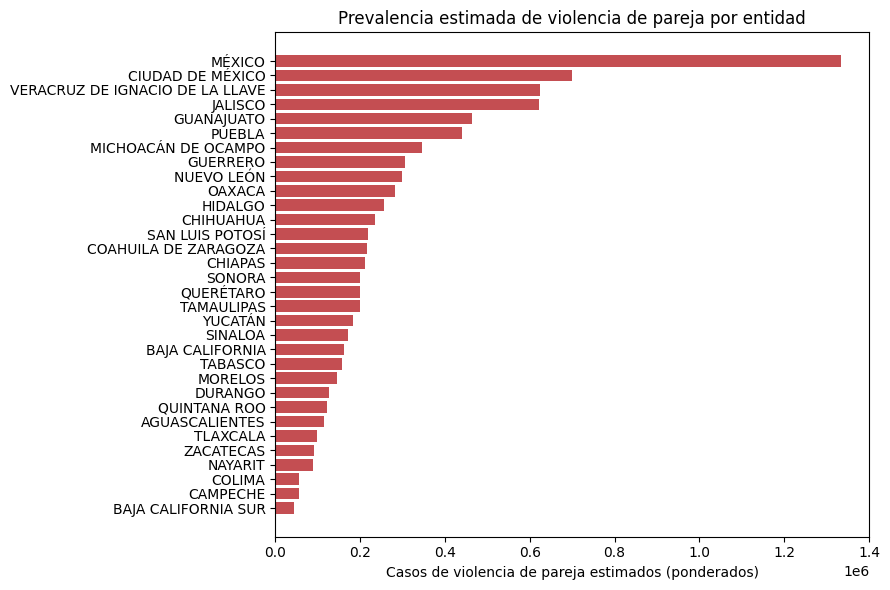

In [5]:
fig = graficar_prevalencia_entidad(casos, ruta_salida=str(RUTA_REPORTS_FIGURES / "prevalencia_por_entidad.png"))

**Interpretación de la gráfica:** Vemos que las entidades con mayor población (Estado
de México, Ciudad de México, Veracruz, Jalisco) encabezan la lista en términos
absolutos, esto es esperable, porque a más mujeres encuestadas y expandidas,
más casos estimados en términos brutos. Por eso la curva de Lorenz y el Gini
son más informativos que esta gráfica sola: miden la concentración relativa,
no el volumen absoluto.

Coeficiente de Gini (casos de violencia por entidad): 0.4180


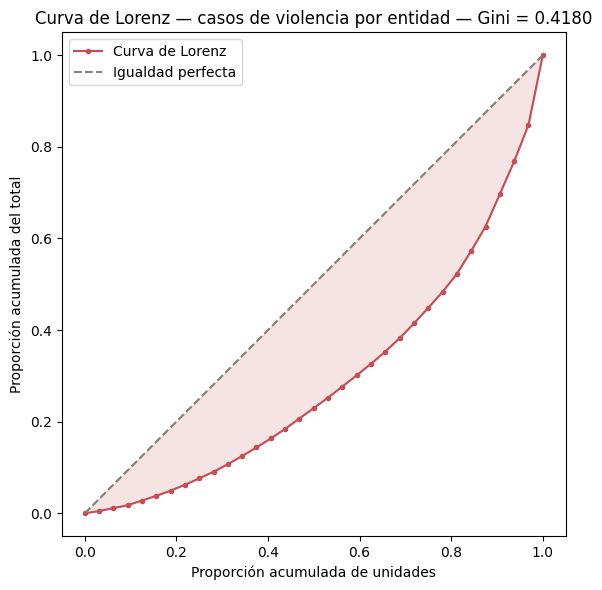

In [6]:
valores = casos["casos_ponderados"].to_numpy()
gini_entidades = calcular_gini(valores)

fig2 = graficar_curva_lorenz(
    valores, gini_entidades,
    titulo="Curva de Lorenz — casos de violencia por entidad",
    ruta_salida=str(RUTA_REPORTS_FIGURES / "curva_lorenz_entidades.png"),
)

print(f"Coeficiente de Gini (casos de violencia por entidad): {gini_entidades:.4f}")

**Interpretación:** el coeficiente de Gini indica una concentración
**moderada**: no es un reparto perfectamente homogéneo,pero tampoco está extremadamente concentrado en muy pocas
entidades. La curva de Lorenz se aleja visiblemente de la
diagonal de igualdad perfecta, mostrando que un grupo de entidades grandes
concentra una fracción desproporcionada de los casos estimados algo que es
consistente con que estas entidades también concentran más población